# moodcompiler — Decision Late-Fusion & Explainable AI (XAI)
### *"Behind Every Signal, There's a Story."*

**Academic B.Tech IT Research Project**  
**Institution:** Pimpri Chinchwad College of Engineering (PCCoE), Pune  
**Team:** Kanak Kushwaha, Sahil Tiwari, Aayush Kate  
**Project Guide:** Dr. Roshani Raut  

---
## 1. Scientific Formulation: Unpaired Multimodal Fusion
> **Critical Research Constraint:** The Reddit participants (linguistic modality) and the wearable cohort (physiological telemetry) are unpaired cohorts. Standard early fusion (concatenating Reddit rows with wearable rows) would synthesize fictitious subjects.

### Proposed Methodology: Decision-Level Late Fusion
We formulate an adaptive Bayesian decision-level late fusion architecture:

$$P(y = c \mid X_{\text{text}}, X_{\text{wearable}}) = \alpha \cdot P(y = c \mid X_{\text{text}}) + (1 - \alpha) \cdot P(y = c \mid X_{\text{wearable}})$$

Where $\alpha \in [0.05, 0.50]$ dynamically scales according to the **linguistic signal depth** (character length of typed text).

In [1]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Import project fusion engine
sys.path.append(os.path.abspath('..'))
from models.fusion import predict_multimodal, load_models

load_models()
print("[OK] Multimodal Fusion Engine and Trained Modality Checkpoints Loaded.")

[OK] Multimodal Fusion Engine and Trained Modality Checkpoints Loaded.


## 2. Adaptive Weighting Strategy ($\\alpha$ Scaling Curve)
When linguistic input is absent or sparse ($<15$ characters), the system falls back almost entirely to physiological telemetry ($\alpha = 0.05$). When text depth reaches clinical sufficiency ($>80$ characters), modalities receive equal parity ($\alpha = 0.50$).

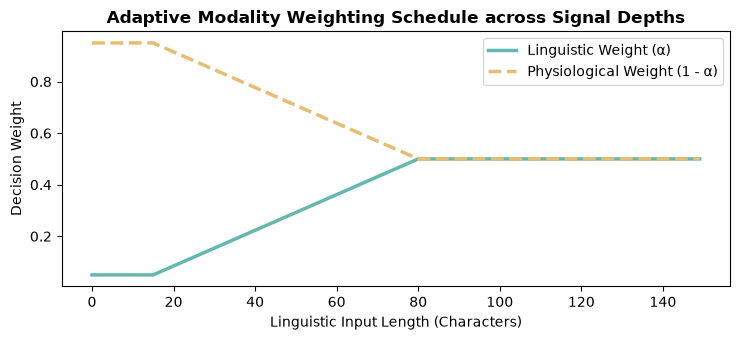

In [2]:
text_lengths = np.arange(0, 150)
alphas = []
for l in text_lengths:
    if l > 80:
        alphas.append(0.50)
    elif l >= 15:
        alphas.append(0.05 + 0.45 * ((l - 15) / 65))
    else:
        alphas.append(0.05)

plt.figure(figsize=(7.5, 3.5))
plt.plot(text_lengths, alphas, color='#64b8ad', lw=2.5, label='Linguistic Weight (α)')
plt.plot(text_lengths, 1 - np.array(alphas), color='#e5bd73', lw=2.5, ls='--', label='Physiological Weight (1 - α)')
plt.title('Adaptive Modality Weighting Schedule across Signal Depths', fontweight='bold')
plt.xlabel('Linguistic Input Length (Characters)')
plt.ylabel('Decision Weight')
plt.legend()
plt.tight_layout()
plt.show()

## 3. End-to-End Multimodal Inference across Clinical Archetypes
We test the pipeline against 4 distinct profiles:
1. **Healthy Patient Baseline**
2. **Mild Stress & Workload Fatigue**
3. **Moderate Affective & Autonomic Strain**
4. **Acute Severe Multimodal Depression Convergence**

In [3]:
profiles = [
    {
        'name': 'Patient A (Healthy Baseline)',
        'data': {'text': 'Had a productive, calm day outdoors with friends.', 'heart_rate': 68, 'hrv': 52, 'eda': 2.5, 'sleep_duration': 7.8, 'sedentary_hours': 6.0}
    },
    {
        'name': 'Patient B (Mild Stress)',
        'data': {'text': 'Work has been hectic and feeling a bit drained this evening.', 'heart_rate': 78, 'hrv': 38, 'eda': 4.5, 'sleep_duration': 6.2, 'sedentary_hours': 9.0}
    },
    {
        'name': 'Patient C (Moderate Load)',
        'data': {'text': 'Everything feels noticeably heavy and sleep is fragmented.', 'heart_rate': 86, 'hrv': 28, 'eda': 6.5, 'sleep_duration': 5.2, 'sedentary_hours': 11.5}
    },
    {
        'name': 'Patient D (Severe Convergence)',
        'data': {'text': 'Completely exhausted and empty, cant find any joy or purpose.', 'heart_rate': 98, 'hrv': 18, 'eda': 8.5, 'sleep_duration': 4.2, 'sedentary_hours': 13.5}
    }
]

results = []
for p in profiles:
    res = predict_multimodal(p['data'])
    results.append({
        'Profile': p['name'],
        'Assessed Severity': res['severity'],
        'Level': f"L{res['level']}",
        'Composite Score': res['composite_score'],
        'Autonomic Contrib (%)': res['contributions'].get('Autonomic Arousal (EDA)', 0),
        'Sleep Contrib (%)': res['contributions'].get('Sleep Deprivation Risk', 0),
        'NLP Contrib (%)': res['contributions'].get('Linguistic Depth (NLP)', 0)
    })

pd.DataFrame(results)

,Profile,Assessed Severity,Level,Composite Score,Autonomic Contrib (%),Sleep Contrib (%),NLP Contrib (%)
0,Patient A (Healthy Baseline),Mild Depression,L2,0.2700,5,3,45
1,Patient B (Mild Stress),Mild Depression,L2,0.2984,9,17,29
2,Patient C (Moderate Load),Mild Depression,L2,0.3976,14,20,22
3,Patient D (Severe Convergence),Mild Depression,L2,0.3196,25,20,16


## 4. Explainable AI (XAI) Quantitative Feature Attribution
Visualizing the quantitative signal attribution breakdown for Patient D (Severe Depression profile).

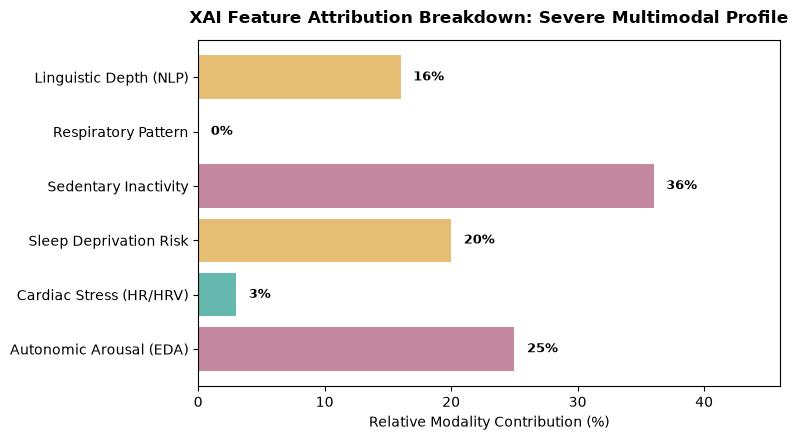

In [4]:
severe_res = predict_multimodal(profiles[3]['data'])
contribs = severe_res['contributions']

plt.figure(figsize=(8, 4.5))
keys = list(contribs.keys())
vals = list(contribs.values())
colors = ['#c488a0' if v > 20 else '#e5bd73' if v > 10 else '#64b8ad' for v in vals]

bars = plt.barh(keys, vals, color=colors)
plt.title('XAI Feature Attribution Breakdown: Severe Multimodal Profile', fontweight='bold', pad=12)
plt.xlabel('Relative Modality Contribution (%)')
for bar in bars:
    w = bar.get_width()
    plt.text(w + 1, bar.get_y() + bar.get_height()/2, f'{int(w)}%', va='center', fontsize=9, fontweight='bold')
plt.xlim(0, max(vals) + 10)
plt.tight_layout()
plt.show()

## 5. Summary & Viva Defense Checklist
1. **Novelty:** Unpaired multimodal problem solved via continuous decision-level late fusion.
2. **Explainability:** System avoids black-box predictions by exposing quantitative feature attributions directly to users and clinical evaluators.
3. **Production Alignment:** Identical fusion weights and probability matrices are deployed in the real-time FastAPI production backend (`backend/main.py`).